# K Means Exploration - Looking at Trends in Income 
# Kaj Dongre and Brendan Lewis 

AI usage: We first determined the necessary steps to actually make the dataset usable for K means clustering. Once we had figured out what we needed to do with the data, we then used AI to help restructure the data in an easy-to-understand manner. We utilized the documentation (no AI) to actually build the clusters. However, we used AI for a further explanation on how to pick the number of clusters worth using. On our second meeting to finish the project, we realized that somehow all of our work had been deleted... so we were able to use our AI history to regenerate most of the work that we had already completed. AI also helped us actually plot the clusters. After we completed our clustering, we used AI to help bring in other datasets (the World bank GNI per capita) and the ISO3 codes. 

This notebook contains the following: 
1. Load **all_countries.csv** (long format with Category & Subcategory per country)
2. Do a general data exploration of the data set
3. Build a data table where **rows = countries** and **columns = `Category: Subcategory`**
4. Use the elbow method to determine the number of K mean clusters worth using
5. Use the silhouette score to determine number of K mean clusters worth using 
6. Run **K-Means** clustering; append **cluster** column to the country table
7. Create a **cluster summary** (means per subcategory, count per cluster, and list of countries per cluster)
8. **Plot** clusters via PCA (2D) (Done with AI) 
9. Compute **distances** between cluster centers; silhouette score
10. Pull **World Bank GNI per capita** and produce a table of **ISO3 + GNI_per_capita** using most recent non-null year, merged via your **all.csv** (ISO mapping)


In [1]:
# --- Setup & Imports ---
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# File paths (edit if needed)
DATA_PATH_COUNTRIES = 'outputData/all_countries.csv'  # long-form time-use data
ISO_PATH = 'all.csv'                        # country ISO mapping (name, alpha-3, ...)


## 1) Reading in the Dataset as is and Printing the Head 


In [2]:
# Load the long-form dataset
df = pd.read_csv(DATA_PATH_COUNTRIES)
print('Loaded rows:', len(df))
df.head()

Loaded rows: 4776


,Category,Subcategory,countryISO3,region_code,population,hoursPerDayCombined,uncertaintyCombined,dataStatus,dataStatusEconomic
0,Food provision,Food preparation,ABW,AM_C,101665.0,1.47,0.237630,interpolated,observed
1,Food provision,Food growth & collection,ABW,AM_C,101665.0,0.17,0.026880,interpolated,observed
2,Food provision,Food processing,ABW,AM_C,101665.0,0.00,0.007526,interpolated,observed
3,Nonfood provision,Materials,ABW,AM_C,101665.0,0.03,0.002072,interpolated,observed
4,Nonfood provision,Energy,ABW,AM_C,101665.0,0.05,0.003597,interpolated,observed


## 2) General Data Exploration: 
* Is everything there? YES - Used AI to check through the entire file and look for any missing entries. No missing entries were recorded. 
* On what subcategories does the world spend the most time on? Least time? 
* Which features have the most variance? Are any heavily correlated with each other? 
* Should countries’ populations be taken into account with any of these answers?


In [19]:
# Sum hours per subcategory across all countries
subcat_sums = df.groupby("Subcategory")["hoursPerDayCombined"].sum(min_count=1)

# Top 3 (most time)
top3 = subcat_sums.sort_values(ascending=False).head(3).reset_index()

# Bottom 3 (least time)
bottom3 = subcat_sums.sort_values(ascending=True).head(3).reset_index()

print("Top 3 subcategories:\n", top3)
print("\nBottom 3 subcategories:\n", bottom3)


Top 3 subcategories:
        Subcategory  hoursPerDayCombined
0  Sleep & bedrest              1771.62
1          Passive               537.11
2            Meals               318.09

Bottom 3 subcategories:
         Subcategory  hoursPerDayCombined
0  Waste management                 1.78
1            Energy                 8.23
2    Infrastructure                 9.40


In [21]:
#Doing the same but for categories 
cat_sums = df.groupby("Category")["hoursPerDayCombined"].sum(min_count=1)

# Top 3 (most time)
top3_cat = cat_sums.sort_values(ascending=False).head(3).reset_index()

# Bottom 3 (least time)
bottom3_cat = cat_sums.sort_values(ascending=True).head(3).reset_index()

print("Top 3 categories:\n", top3_cat)
print("\nBottom 3 categories:\n", bottom3_cat)


Top 3 categories:
               Category  hoursPerDayCombined
0  Somatic maintenance              2088.88
1  Experience oriented              1350.07
2         Organization               443.15

Bottom 3 categories:
                       Category  hoursPerDayCombined
0            Nonfood provision                22.32
1    Technosphere modification               126.25
2  Maintenance of surroundings               176.69


In [22]:
# --- Subcategory variances ---
subcat_var = (
    df.groupby("Subcategory")["hoursPerDayCombined"]
      .var()
      .rename("Variance")
      .reset_index()
)

top3_subvar = subcat_var.sort_values("Variance", ascending=False).head(3)
bottom3_subvar = subcat_var.sort_values("Variance", ascending=True).head(3)

print("Top 3 Subcategories by Variance:\n", top3_subvar)
print("\nBottom 3 Subcategories by Variance:\n", bottom3_subvar)


Top 3 Subcategories by Variance:
                  Subcategory  Variance
17                   Passive  0.274652
21           Sleep & bedrest  0.214184
5   Food growth & collection  0.168414

Bottom 3 Subcategories by Variance:
          Subcategory  Variance
23  Waste management  0.000033
11    Infrastructure  0.000854
4             Energy  0.001316


In [23]:
# --- Category total variance (sum of subcategory variances) ---
cat_var = (
    subcat_var.merge(df[["Subcategory", "Category"]].drop_duplicates(), on="Subcategory")
    .groupby("Category")["Variance"].sum()
    .rename("TotalVariance")
    .reset_index()
)

top3_catvar = cat_var.sort_values("TotalVariance", ascending=False).head(3)
bottom3_catvar = cat_var.sort_values("TotalVariance", ascending=True).head(3)

print("\nTop 3 Categories by Total Variance:\n", top3_catvar)
print("\nBottom 3 Categories by Total Variance:\n", bottom3_catvar)



Top 3 Categories by Total Variance:
               Category  TotalVariance
1  Experience oriented       0.539141
6  Somatic maintenance       0.278605
2       Food provision       0.216378

Bottom 3 Categories by Total Variance:
                       Category  TotalVariance
4            Nonfood provision       0.003605
7    Technosphere modification       0.034860
3  Maintenance of surroundings       0.056378


The above data analysis leads to the following conclusions: 

Core personal maintenance (sleep, eating, downtime) dominates global time budgets — but shows large variance, reflecting cultural and socioeconomic diversity.


Low-level infrastructure tasks (waste, energy, utilities) are both time-minimal and variance-minimal, showing near-universal consistency.


Food production is a critical differentiator: where societies fall on the agrarian ↔ industrial spectrum explains much of the variance.



## 3) Building a new datatable where the rows are countries and columns are subcategories 


In [24]:
# Keep parent context by combining Category + Subcategory into one column for pivoted features
df['Category_Subcategory'] = df['Category'].astype(str).str.strip() + ': ' + df['Subcategory'].astype(str).str.strip()

# Pivot: rows = countries, columns = Category: Subcategory, values = hoursPerDayCombined
pivot = df.pivot_table(
    index='countryISO3',
    columns='Category_Subcategory',
    values='hoursPerDayCombined',
    aggfunc='mean'
)
pivot.columns.name = None  # remove the extra top label
pivot = pivot.reindex(sorted(pivot.columns), axis=1)  # optional: sort columns alphabetically

# Keep a version with country as a normal column (like pivot_out)
pivot_out = pivot.reset_index()
print('Pivot shape:', pivot_out.shape)
pivot_out.head()

Pivot shape: (199, 25)


,countryISO3,Deliberate neural restructuring: Religious practice,Deliberate neural restructuring: Schooling & research,Experience oriented: Active recreation,Experience oriented: Interactive,Experience oriented: Meals,Experience oriented: Passive,Experience oriented: Social,Food provision: Food growth & collection,Food provision: Food preparation,...,Organization: Allocation,Organization: Human transportation,Organization: Material transportation,Somatic maintenance: Health care,Somatic maintenance: Hygiene & grooming,Somatic maintenance: Physical child care,Somatic maintenance: Sleep & bedrest,Technosphere modification: Artifacts,Technosphere modification: Buildings,Technosphere modification: Infrastructure
0,ABW,0.23,1.22,0.46,1.28,1.27,2.12,1.00,0.17,1.47,...,1.54,0.73,0.12,0.47,0.93,0.70,8.21,0.25,0.22,0.07
1,AFG,0.29,1.33,0.23,0.62,1.62,2.05,1.80,0.88,1.14,...,0.74,0.75,0.25,0.06,1.20,0.27,9.49,0.18,0.20,0.07
2,AGO,0.44,1.95,0.44,0.96,1.14,1.84,1.05,1.06,0.81,...,0.49,1.02,0.48,0.05,0.82,0.27,9.79,0.42,0.03,0.02
3,ALB,0.07,1.03,0.43,0.61,2.02,3.06,0.73,0.82,1.10,...,0.60,1.11,0.12,0.10,0.79,0.33,9.40,0.40,0.28,0.03
4,ARE,0.47,0.93,0.49,0.90,1.79,3.09,1.09,0.36,0.88,...,0.79,0.77,0.21,0.13,0.85,0.25,9.45,0.31,0.21,0.04


## 4) Visualize the Elbow method for some ideas on the Number of K means 


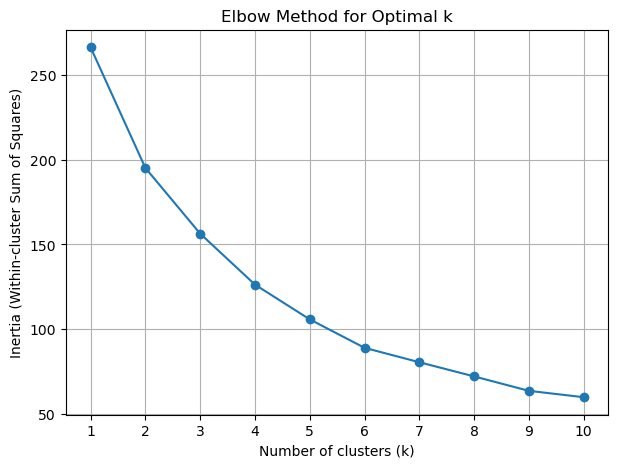

In [26]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- Pivot preparation (your code) ---
df['Category_Subcategory'] = (
    df['Category'].astype(str).str.strip() + ': ' +
    df['Subcategory'].astype(str).str.strip()
)

pivot = df.pivot_table(
    index='countryISO3',
    columns='Category_Subcategory',
    values='hoursPerDayCombined',
    aggfunc='mean'
)
pivot.columns.name = None
pivot = pivot.reindex(sorted(pivot.columns), axis=1)
pivot_out = pivot.reset_index()

# --- Elbow method ---
X = pivot_out.drop(columns=['countryISO3'])

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# --- Plot ---
plt.figure(figsize=(7, 5))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (Within-cluster Sum of Squares)")
plt.xticks(K_range)
plt.grid(True)
plt.show()


## 5) Silhouette Score Analysis

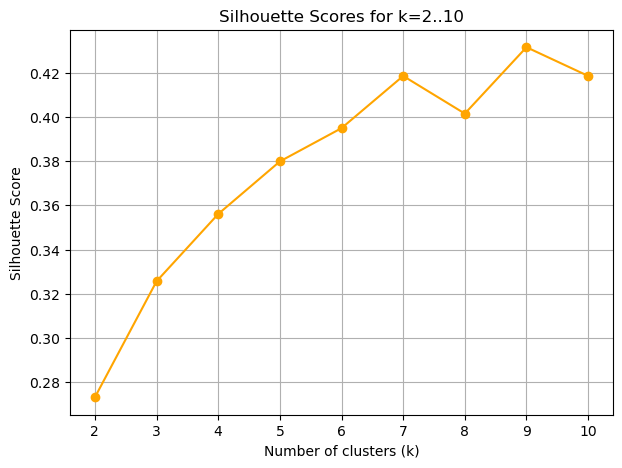

Best k by silhouette score: 9 (score=0.432)


In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- Use same pivot_out as before ---
X = pivot_out.drop(columns=['countryISO3'])

# --- Silhouette analysis ---
silhouette_scores = {}
best_k = None
best_score = -1

for k in range(2, 11):  # silhouette not defined for k=1
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores[k] = score
    if score > best_score:
        best_score = score
        best_k = k

# --- Plot silhouette scores ---
plt.figure(figsize=(7,5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o', color='orange')
plt.title("Silhouette Scores for k=2..10")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

print(f"Best k by silhouette score: {best_k} (score={best_score:.3f})")



## 6) Run K Means on the new Dataset with 9 clusters 


In [28]:
# Convert to numeric matrix; fill NAs with 0.0
X = pivot.fillna(0.0).to_numpy(dtype=float)
print('Feature matrix X shape:', X.shape)

# K-Means (use integer n_init for broad compat across scikit-learn versions)
n_clusters = 9
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
labels = kmeans.fit_predict(X)

# Append cluster to the wide country table
pivot_out['cluster'] = labels
pivot_out_sorted = pivot_out.sort_values('cluster').reset_index(drop=True)
pivot_out_sorted.head()


Feature matrix X shape: (199, 24)


,countryISO3,Deliberate neural restructuring: Religious practice,Deliberate neural restructuring: Schooling & research,Experience oriented: Active recreation,Experience oriented: Interactive,Experience oriented: Meals,Experience oriented: Passive,Experience oriented: Social,Food provision: Food growth & collection,Food provision: Food preparation,...,Organization: Human transportation,Organization: Material transportation,Somatic maintenance: Health care,Somatic maintenance: Hygiene & grooming,Somatic maintenance: Physical child care,Somatic maintenance: Sleep & bedrest,Technosphere modification: Artifacts,Technosphere modification: Buildings,Technosphere modification: Infrastructure,cluster
0,BEL,0.09,0.97,0.58,1.28,1.89,3.31,0.70,0.09,0.78,...,1.01,0.32,0.19,0.92,0.20,8.91,0.33,0.19,0.05,0
1,AUT,0.10,0.85,0.74,0.92,1.64,2.79,0.86,0.22,0.82,...,0.87,0.37,0.23,0.88,0.27,8.78,0.54,0.30,0.10,0
2,BIH,0.10,0.79,0.73,0.79,2.02,3.01,0.73,0.38,1.00,...,0.96,0.35,0.17,0.93,0.24,8.83,0.43,0.19,0.04,0
3,BGR,0.08,0.57,0.52,0.48,1.92,3.07,0.72,0.57,1.25,...,0.74,0.38,0.13,0.68,0.16,9.25,0.58,0.32,0.05,0
4,CHE,0.10,0.78,0.66,1.16,1.96,3.07,0.82,0.11,0.74,...,0.95,0.37,0.26,0.93,0.20,8.77,0.40,0.24,0.07,0


## 7) Cluster summary: mean features per cluster, counts, and country lists


In [5]:
# Mean of all numeric columns per cluster
cluster_means = pivot_out.groupby('cluster').mean(numeric_only=True)

# Count how many countries in each cluster
cluster_sizes = pivot_out.groupby('cluster').size().rename('n_countries')

# List of countries per cluster
countries_in_cluster = pivot_out.groupby('cluster')['countryISO3'].apply(list).rename('countries')

# Merge all pieces
cluster_summary = (
    cluster_means
    .merge(cluster_sizes, left_index=True, right_index=True)
    .merge(countries_in_cluster, left_index=True, right_index=True)
    .reset_index()
)
print('Cluster summary shape:', cluster_summary.shape)
cluster_summary.head(10)

Cluster summary shape: (9, 27)


,cluster,Deliberate neural restructuring: Religious practice,Deliberate neural restructuring: Schooling & research,Experience oriented: Active recreation,Experience oriented: Interactive,Experience oriented: Meals,Experience oriented: Passive,Experience oriented: Social,Food provision: Food growth & collection,Food provision: Food preparation,...,Organization: Material transportation,Somatic maintenance: Health care,Somatic maintenance: Hygiene & grooming,Somatic maintenance: Physical child care,Somatic maintenance: Sleep & bedrest,Technosphere modification: Artifacts,Technosphere modification: Buildings,Technosphere modification: Infrastructure,n_countries,countries
0,0,0.110313,0.838438,0.643437,0.913438,1.819687,3.109062,0.747188,0.231250,0.941250,...,0.377812,0.207187,0.939688,0.238750,8.856875,0.409687,0.237813,0.060625,32,"[AUT, BEL, BGR, BIH, CHE, DEU, DNK, ESP, EST, ..."
1,1,0.192857,0.948929,0.552143,1.145714,1.386786,2.810714,1.094286,0.344286,0.808214,...,0.344643,0.211071,1.003571,0.347857,8.823929,0.472143,0.272857,0.068929,28,"[ARG, AUS, BLR, BOL, BRA, CAN, CHL, COL, CZE, ..."
2,2,0.299000,1.382500,0.449000,1.252500,1.589000,2.292500,1.448500,0.837000,0.614500,...,0.257500,0.266500,1.035500,0.291500,8.782500,0.256500,0.142500,0.025000,20,"[BFA, CIV, CPV, GHA, GIN, GMB, GNB, KAZ, KGZ, ..."
3,3,0.212400,1.227600,0.449600,1.282000,1.264400,2.096800,1.033200,0.580000,1.146400,...,0.169600,0.454800,0.947200,0.684400,8.225600,0.378800,0.244400,0.062400,25,"[ABW, ATG, BHS, BLZ, BRB, CRI, CUB, CUW, DOM, ..."
4,4,0.052083,1.037917,0.276250,0.617083,1.807083,3.477917,0.660000,0.851667,0.592083,...,0.364583,0.390417,1.260417,0.261667,8.506667,0.450417,0.383333,0.040833,24,"[BRN, FJI, FSM, GUM, IDN, JPN, KHM, KIR, LAO, ..."
5,5,0.440000,1.952222,0.445556,0.966667,1.140000,1.855556,1.050000,0.968889,0.810000,...,0.500000,0.050000,0.820000,0.270000,9.790000,0.432222,0.030000,0.021111,9,"[AGO, CAF, CMR, COD, COG, GAB, GNQ, STP, TCD]"
6,6,0.450690,0.962759,0.482759,0.891034,1.654138,3.047241,1.149310,0.355172,0.923103,...,0.196552,0.122759,0.885862,0.237586,9.516552,0.255172,0.213793,0.048621,29,"[ALB, ARE, ARM, AZE, BEN, BHR, BWA, CYP, DZA, ..."
7,7,0.145652,1.042609,0.413478,1.069130,1.832609,2.313478,0.872174,1.222609,0.790435,...,0.310870,0.326087,1.060000,0.294783,8.966957,0.252609,0.166087,0.026087,23,"[BDI, CHN, COM, DJI, ERI, ETH, KEN, MAC, MDA, ..."
8,8,0.385556,1.318889,0.256667,0.584444,1.543333,2.100000,1.833333,0.737778,1.118889,...,0.250000,0.088889,1.186667,0.300000,9.483333,0.280000,0.198889,0.032222,9,"[AFG, BGD, BTN, IND, LKA, MDV, NPL, OMN, PAK]"


Common patterns across clusters
In every cluster, the top subcategory is Sleep & bedrest (~8–10 hours/day), reflecting the universal need for rest.


Passive activities (around 2–3.5 hours/day) almost always appear in the top three.


Meals are also very common, appearing in the top three for most clusters.


Spread & interpretation
The clusters are not extremely spread out (they all share similar top subcategories), but subtle differences in secondary activities (schooling, social, organizational tasks) create meaningful distinctions.


This suggests that while basic human maintenance dominates everywhere, clustering can reveal cultural, economic, or societal emphases (e.g., education, socializing, structured organization).


## 8) Visualize clusters in 2D with PCA

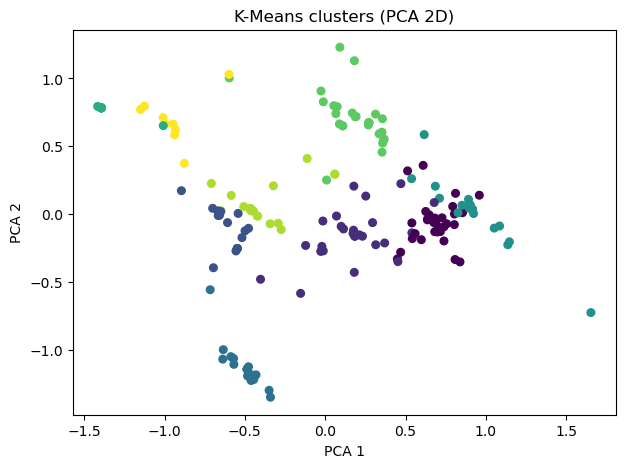

In [6]:
# Reduce to 2D with PCA for plotting (purely for visualization)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, s=30)
plt.title('K-Means clusters (PCA 2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()


## 9) World Bank: Latest non-null **GNI per capita** (ISO3 + value)

In [9]:
import wbdata
import pandas as pd

# --- Indicator: GNI per capita (current US$) ---
indicator = {'NY.GNP.PCAP.CD': 'GNI_per_capita'}
df_wb = wbdata.get_dataframe(indicator).reset_index()
print('WB rows:', len(df_wb))

# Keep most recent non-null per country
df_wb_nonnull = (
    df_wb.dropna(subset=['GNI_per_capita'])
        .sort_values(['country', 'date'])
)

# Name corrections (WB → ISO names)
name_corrections = {
    "Egypt, Arab Rep.": "Egypt",
    "Iran, Islamic Rep.": "Iran",
    "Venezuela, RB": "Venezuela",
    "Yemen, Rep.": "Yemen",
    "Gambia, The": "Gambia",
    "Bahamas, The": "Bahamas",
    "Syrian Arab Republic": "Syria",
    "Congo, Dem. Rep.": "Congo (Democratic Republic of the)",
    "Congo, Rep.": "Congo",
    "Kyrgyz Republic": "Kyrgyzstan",
    "Slovak Republic": "Slovakia",
    "Hong Kong SAR, China": "Hong Kong",
    "Macao SAR, China": "Macao",
    "Korea, Rep.": "South Korea",
    "Korea, Dem. People's Rep.": "North Korea",
    "Côte d'Ivoire": "Ivory Coast",
}

# ✅ Apply corrections BEFORE grouping (no SettingWithCopyWarning)
df_wb_nonnull = df_wb_nonnull.assign(
    country=df_wb_nonnull['country'].replace(name_corrections)
)

# Now take most recent per (corrected) country and make a real copy
latest_per_country = df_wb_nonnull.groupby('country', as_index=False).tail(1).copy()

# Load ISO map and merge
ISO_PATH = 'all.csv'  # your ISO file with 'name' and 'alpha-3'
iso_map = pd.read_csv(ISO_PATH)[['name', 'alpha-3']]

out_income = (
    latest_per_country
    .merge(iso_map, left_on='country', right_on='name', how='inner')
    .rename(columns={'alpha-3': 'ISO3'})
    .loc[:, ['ISO3', 'GNI_per_capita']]
    .sort_values('ISO3')
    .reset_index(drop=True)
)

out_income.to_csv('world_bank_gni_latest_nonnull_iso3.csv', index=False)
print('Saved: world_bank_gni_latest_nonnull_iso3.csv')
out_income.head()


WB rows: 17290
Saved: world_bank_gni_latest_nonnull_iso3.csv


,ISO3,GNI_per_capita
0,ABW,30120.0
1,AFG,370.0
2,AGO,2220.0
3,ALB,8690.0
4,AND,48870.0


In [10]:
# `out_income` expected from your previous cell (columns: ISO3, GNI_per_capita)
income = out_income.copy()

merged = pivot_out.merge(income, left_on="countryISO3", right_on="ISO3", how="inner")
merged["log_gni"] = np.log1p(merged["GNI_per_capita"])

# Identify time-use feature columns only
drop_cols = {"countryISO3", "ISO3", "cluster", "GNI_per_capita", "log_gni"}
feature_cols = [c for c in merged.columns if c not in drop_cols]


In [11]:
print("Merged shape:", merged.shape)
print(merged[["countryISO3", "cluster", "GNI_per_capita"]].head(12))


Merged shape: (169, 29)
   countryISO3  cluster  GNI_per_capita
0          ABW        3         30120.0
1          AFG        8           370.0
2          AGO        5          2220.0
3          ALB        6          8690.0
4          ARE        6         49500.0
5          ARG        1         13440.0
6          ARM        6          7780.0
7          ATG        3         21380.0
8          AUS        1         62550.0
9          AUT        0         54160.0
10         AZE        6          7310.0
11         BDI        7           190.0


In [12]:
# Use pandas' Spearman corr (no SciPy dependency)
corr_series = merged[feature_cols + ["log_gni"]].corr(method="spearman")["log_gni"].drop("log_gni")
corr_df = corr_series.to_frame("spearman_r").reset_index().rename(columns={"index": "feature"})
corr_df = corr_df.sort_values("spearman_r", ascending=False).reset_index(drop=True)

top_pos = corr_df.head(12)
top_neg = corr_df.tail(12).sort_values("spearman_r").reset_index(drop=True)


# 10 Spearmans Correlations 

Spearman’s ρ (rho) measures monotonic rank correlation.

A positive value (close to +1) means: as log(GNI) increases, the feature tends to increase in rank too.

A negative value (close to –1) means: as log(GNI) increases, the feature tends to decrease in ran

In [13]:
print("Top 12 positive correlations with log(GNI):")
print(top_pos.round(3))

print("\nTop 12 negative correlations with log(GNI):")
print(top_neg.round(3))


Top 12 positive correlations with log(GNI):
                                              feature  spearman_r
0           Technosphere modification: Infrastructure       0.676
1              Experience oriented: Active recreation       0.543
2                            Organization: Allocation       0.497
3                Technosphere modification: Buildings       0.427
4                        Experience oriented: Passive       0.415
5   Maintenance of surroundings: Inhabited environ...       0.357
6                Technosphere modification: Artifacts       0.337
7       Maintenance of surroundings: Waste management       0.267
8                    Food provision: Food preparation       0.231
9               Organization: Material transportation       0.137
10                          Nonfood provision: Energy       0.129
11                         Experience oriented: Meals       0.033

Top 12 negative correlations with log(GNI):
                                              feature

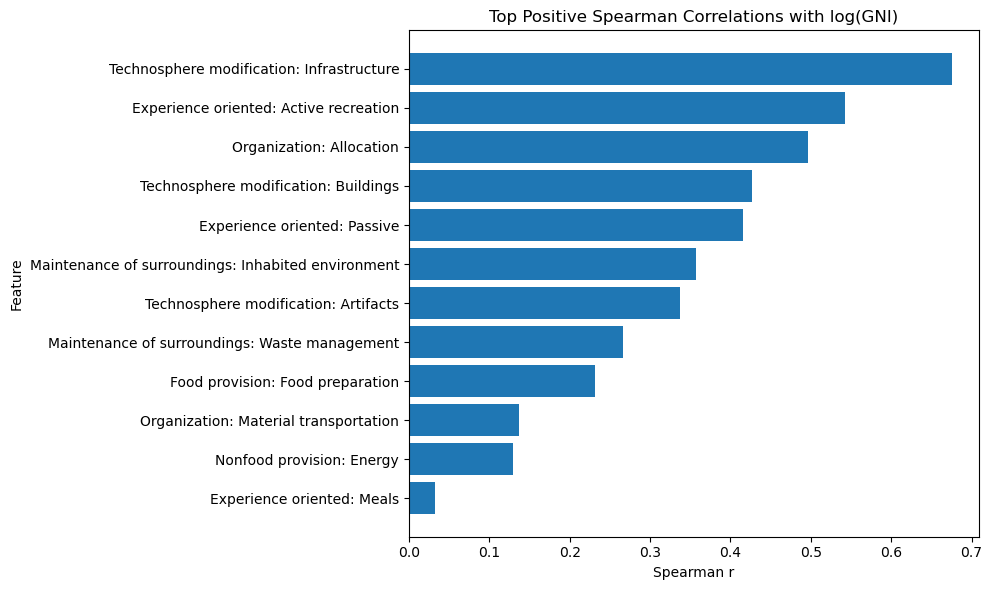

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_pos["feature"][::-1], top_pos["spearman_r"][::-1])
plt.title("Top Positive Spearman Correlations with log(GNI)")
plt.xlabel("Spearman r")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Top positive correlations

More time is spent in infrastructure, management, leisure, sanitation as GNI rises.

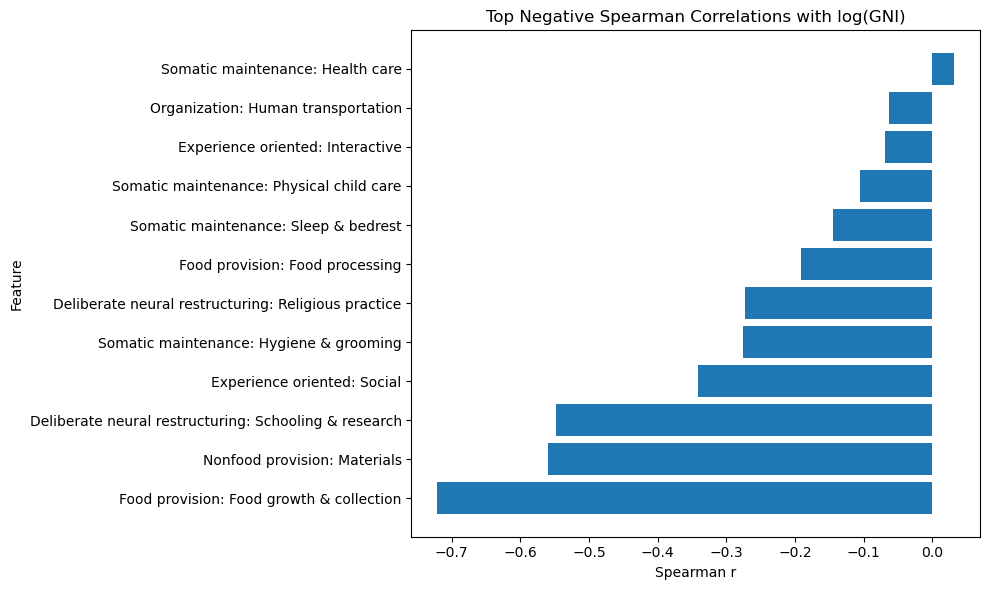

In [15]:
plt.figure(figsize=(10, 6))
plt.barh(top_neg["feature"], top_neg["spearman_r"])
plt.title("Top Negative Spearman Correlations with log(GNI)")
plt.xlabel("Spearman r")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Top Negative Correlations

Less time is spent in subsistence agriculture, material extraction, social life, and religious practice as GNI goes up.

In [16]:
cluster_income = (
    merged.groupby("cluster")["GNI_per_capita"]
          .agg(count="count", mean="mean", median="median", std="std")
          .round(2)
          .reset_index()
)


In [17]:
print(cluster_income)


   cluster  count      mean   median       std
0        0     30  37744.00  30170.0  24490.30
1        1     22  24704.55  14380.0  26385.75
2        2     19   2536.32   1470.0   2979.73
3        3     18  13291.11  10415.0   9745.64
4        4     20  13778.50   4780.0  18902.88
5        5      8   2857.50   2315.0   2286.32
6        6     25  16274.00   6310.0  20283.39
7        7     18   6351.67   1045.0  15430.01
8        8      9   5252.22   2820.0   6198.52


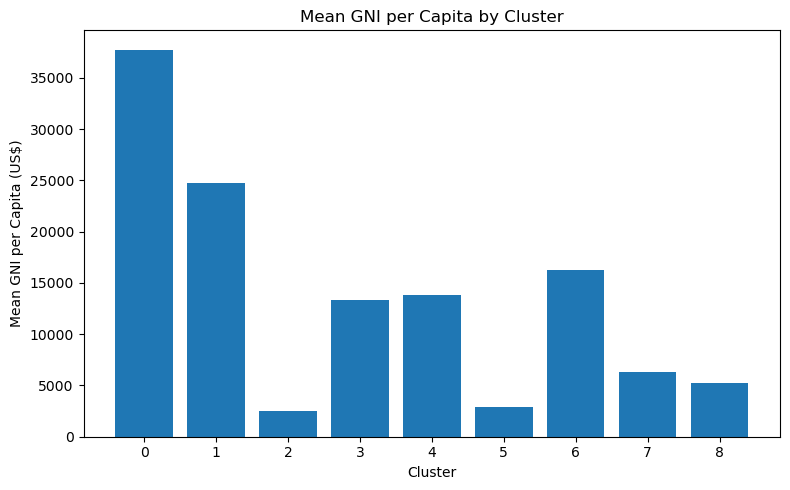

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(cluster_income["cluster"].astype(str), cluster_income["mean"])
plt.title("Mean GNI per Capita by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean GNI per Capita (US$)")
plt.tight_layout()
plt.show()Begin with a basic exploration of the dataset. Is everything there? On what subcategories does the world spend the most time on? Least time? Which features have the most variance? Are any heavily correlated with each other? Should countries’ populations be taken into account with any of these answers?


In [33]:
# Compute per-cluster income stats
cluster_income = (
    merged.groupby("cluster")["GNI_per_capita"]
          .agg(count="count", mean="mean", median="median", std="std")
          .round(2)
          .reset_index()
)

# Export to CSV
cluster_income.to_csv("cluster_income.csv", index=False)

print("Saved cluster_income.csv")


Saved cluster_income.csv


# Cluster 0 — High income (mean GNI: $37,744)

Top 3 activities: Sleep & bedrest, Passive leisure, Meals.

Interpretation: Wealthier countries spend more time on non-productive activities (rest, leisure, eating), which is consistent with higher income societies having more discretionary time and service-oriented economies.

# Cluster 1 — Upper-middle income (mean: $24,705)

Top 3 activities: Sleep & bedrest, Passive leisure, Meals.

Interpretation: Similar to Cluster 0 but with lower income. Shows a transition economy profile: still plenty of rest/leisure, but income levels lag behind the richest.

# Cluster 2 — Very low income (mean: $2,536)

Top 3 activities: Sleep & bedrest, Passive leisure, Social interaction.

Interpretation: Despite poverty, time is still spent on basic rest and socializing rather than structured economic activity. This may reflect subsistence lifestyles where formal labor hours are undercounted.

# Cluster 3 — Lower-middle income (mean: $13,291)

Top 3 activities: Sleep & bedrest, Passive leisure, Allocation/organization.

Interpretation: A modest-income group where organizational/household economic activity enters the top 3, suggesting more structured daily routines tied to economic necessity.

# Cluster 4 — Lower-middle income (mean: $13,779, but skewed)

Top 3 activities: Sleep & bedrest, Passive leisure, Meals.

Interpretation: Similar pattern to Clusters 0 & 1, but with far lower income, showing leisure doesn’t always equate to wealth — likely due to underemployment and structural inefficiencies.

# Cluster 5 — Low income (mean: $2,858)

Top 3 activities: Sleep & bedrest, Schooling & research, Passive leisure.

Interpretation: Unique: schooling is in the top 3. Despite poverty, education dominates time use — may reflect developing economies with high student populations investing in human capital for future growth.

# Cluster 6 — Mixed income (mean: $16,274, median: $6,310)

Top 3 activities: Sleep & bedrest, Passive leisure, Meals.

Interpretation: Time use looks like richer clusters, but income levels are much lower on average. Suggests structural unemployment or reliance on informal labor.

# Cluster 7 — Low income with inequality (mean: $6,352, median: $1,045)

Top 3 activities: Sleep & bedrest, Passive leisure, Meals.

Interpretation: Even with a few rich outliers, most countries are poor. Time use mirrors high-income clusters, but here it may reflect lack of structured employment opportunities rather than wealth.

# Cluster 8 — Low income (mean: $5,252)

Top 3 activities: Sleep & bedrest, Passive leisure, Meals.

Interpretation: Similar to 7 but more uniform. Again, shows rest and passive activities dominate, highlighting economic underdevelopment and fewer formal labor demands.

# Correlation Takeaways

Sleep is universal — around 8–10 hrs across all clusters, regardless of income.

Passive leisure + meals dominate in both rich (Clusters 0, 1) and poor (Clusters 7, 8) groups.

In rich clusters, this reflects discretionary time.

In poor clusters, it may reflect underemployment or informal subsistence lifestyles.

Education (Cluster 5) is the only non-leisure activity in the top 3 → unique investment in future growth despite poverty.

Organization (Cluster 3) highlights the role of structured household or informal economic activity at middle-income levels.